### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import tensorflow as tf
import tensorflow.keras as keras

#### Collect Fashion mnist data from tf.keras.datasets 

In [2]:
from keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

Using TensorFlow backend.


4423680/4422102 [==============================] - 2s 0us/step


In [3]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(60000, 28, 28) (10000, 28, 28)
(60000,) (10000,)


#### Change train and test labels into one-hot vectors

In [0]:
y_train_hot = keras.utils.to_categorical(y_train)
y_test_hot = keras.utils.to_categorical(y_test)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [5]:
x_train_norm = x_train/255
x_test_norm = x_test/255
x_train_norm = x_train_norm.reshape(-1,28,28,1)
x_test_norm = x_test_norm.reshape(-1,28,28,1)
print(x_train_norm.shape)
print(x_train_norm.shape)
print(x_train_norm[:5].T)

(60000, 28, 28, 1)
(60000, 28, 28, 1)
[[[[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  ...

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]

  [[0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   ...
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]
   [0. 0. 0. 0. 0.]]]]


#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [6]:
model = tf.keras.models.Sequential()
model.add(keras.layers.Dense(200, input_shape=(28,28,1,), activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dropout(0.25))


W0824 03:25:12.371748 139792001804160 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 28, 28, 200)       400       
_________________________________________________________________
dense_1 (Dense)              (None, 28, 28, 100)       20100     
_________________________________________________________________
dropout (Dropout)            (None, 28, 28, 100)       0         
Total params: 20,500
Trainable params: 20,500
Non-trainable params: 0
_________________________________________________________________


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [9]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 28, 28, 200)       400       
_________________________________________________________________
dense_1 (Dense)              (None, 28, 28, 100)       20100     
_________________________________________________________________
dropout (Dropout)            (None, 28, 28, 100)       0         
_________________________________________________________________
flatten (Flatten)            (None, 78400)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                784010    
Total params: 804,510
Trainable params: 804,510
Non-trainable params: 0
_________________________________________________________________


In [10]:
history = model.fit(x_train_norm, y_train_hot,
                    validation_data=(x_test_norm, y_test_hot),
                    batch_size=128,
                    epochs=10)

Train on 60000 samples, validate on 10000 samples
Epoch 1/10
60000/60000 [==============================] - 14s 226us/sample - loss: 0.4898 - acc: 0.8270 - val_loss: 0.4295 - val_acc: 0.8445
Epoch 2/10
60000/60000 [==============================] - 13s 210us/sample - loss: 0.3828 - acc: 0.8623 - val_loss: 0.3960 - val_acc: 0.8579
Epoch 3/10
60000/60000 [==============================] - 13s 211us/sample - loss: 0.3604 - acc: 0.8710 - val_loss: 0.3845 - val_acc: 0.8623
Epoch 4/10
60000/60000 [==============================] - 13s 212us/sample - loss: 0.3514 - acc: 0.8726 - val_loss: 0.3863 - val_acc: 0.8618
Epoch 5/10
60000/60000 [==============================] - 13s 212us/sample - loss: 0.3343 - acc: 0.8789 - val_loss: 0.3773 - val_acc: 0.8630
Epoch 6/10
60000/60000 [==============================] - 13s 212us/sample - loss: 0.3265 - acc: 0.8816 - val_loss: 0.3745 - val_acc: 0.8661
Epoch 7/10
60000/60000 [==============================] - 13s 214us/sample - loss: 0.3167 - acc: 0.8855 

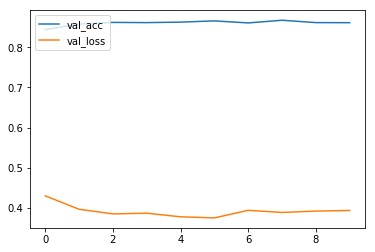

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


# Observation:
With this model max accuracy seems to settle arroubd 86%